# Online Shoppers Purchasing Intention — предсказание покупки

**Задача:** бинарная классификация — предсказать, совершит ли посетитель сайта покупку (`Revenue`) на основе поведения на сайте (просмотренные страницы, время на них, тип трафика и т.д.).

**Датасет:** [Online Shoppers Purchasing Intention Dataset (UCI)](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset), 12 330 сессий, 17 признаков + целевая переменная `Revenue` (bool).

**Почему выбран этот датасет:**
- Реальные табличные данные с миксом числовых и категориальных признаков
- Выраженный дисбаланс классов (~85% / 15%) — можно проверить гипотезы про accuracy vs F1
- Достаточный объём данных для честного train/test split и кросс-валидации

The dataset consists of 10 numerical and 8 categorical attributes.
The 'Revenue' attribute can be used as the class label.

"Administrative", "Administrative Duration", "Informational", "Informational Duration", "Product Related" and "Product Related Duration" represent the number of different types of pages visited by the visitor in that session and total time spent in each of these page categories. The values of these features are derived from the URL information of the pages visited by the user and updated in real time when a user takes an action, e.g. moving from one page to another. The "Bounce Rate", "Exit Rate" and "Page Value" features represent the metrics measured by "Google Analytics" for each page in the e-commerce site. The value of "Bounce Rate" feature for a web page refers to the percentage of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session. The value of "Exit Rate" feature for a specific web page is calculated as for all pageviews to the page, the percentage that were the last in the session. The "Page Value" feature represents the average value for a web page that a user visited before completing an e-commerce transaction. The "Special Day" feature indicates the closeness of the site visiting time to a specific special day (e.g. Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina’s day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8. The dataset also includes operating system, browser, region, traffic type, visitor type as returning or new visitor, a Boolean value indicating whether the date of the visit is weekend, and month of the year.

## Гипотезы

1. **Random Forest превзойдёт логистическую регрессию по ROC-AUC**, потому что связь признаков с покупкой может отказаться нелинейна
2. **При неограниченной глубине дерева решений начнётся переобучение**, т.е. train F1 macro будет расти, а test F1 macro — падать по сравнению с деревом ограниченной глубины.
3. **`PageValues` окажется самым важным признаком** по feature importance случайного леса, так как это прямая метрика ценности страницы для конверсии.
4. **Удаление одного из сильно коррелированных признаков не ухудшит существенно AUC** логистической регрессии
5. **Ridge-регуляризация (L2) обойдёт нерегуляризованную логистическую регрессию по AUC на тесте** за счёт борьбы с мультиколлинеарностью признаков.
6. **F1 macro будет заметно ниже accuracy** из-за дисбаланса классов (~85%/15%).
7. **Отбор топ-10 признаков через SelectKBest не ухудшит существенно качество** по сравнению с полным набором признаков после one-hot кодирования, так как часть признаков может оказаться малоинформативна.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              roc_auc_score, ConfusionMatrixDisplay)

## 1. Загрузка данных

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. EDA

### 2.1 Общая информация и пропуски

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

Пропусков в данных нет

### 2.2 Распределение целевой переменной (дисбаланс классов)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


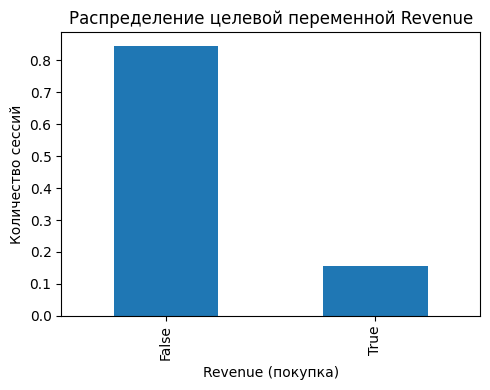

In [3]:
target_counts = df['Revenue'].value_counts(normalize=True)
print(target_counts)

fig, ax = plt.subplots(figsize=(5,4))
target_counts.plot(kind='bar', ax=ax)
ax.set_title('Распределение целевой переменной Revenue')
ax.set_xlabel('Revenue (покупка)')
ax.set_ylabel('Количество сессий')
plt.tight_layout()
plt.show()

Класс `True` (покупка совершена) составляет всего ~15.5% выборки — заметный дисбаланс. Это напрямую влияет на гипотезу №6 (accuracy vs F1 macro).

### 2.3 Распределения числовых признаков

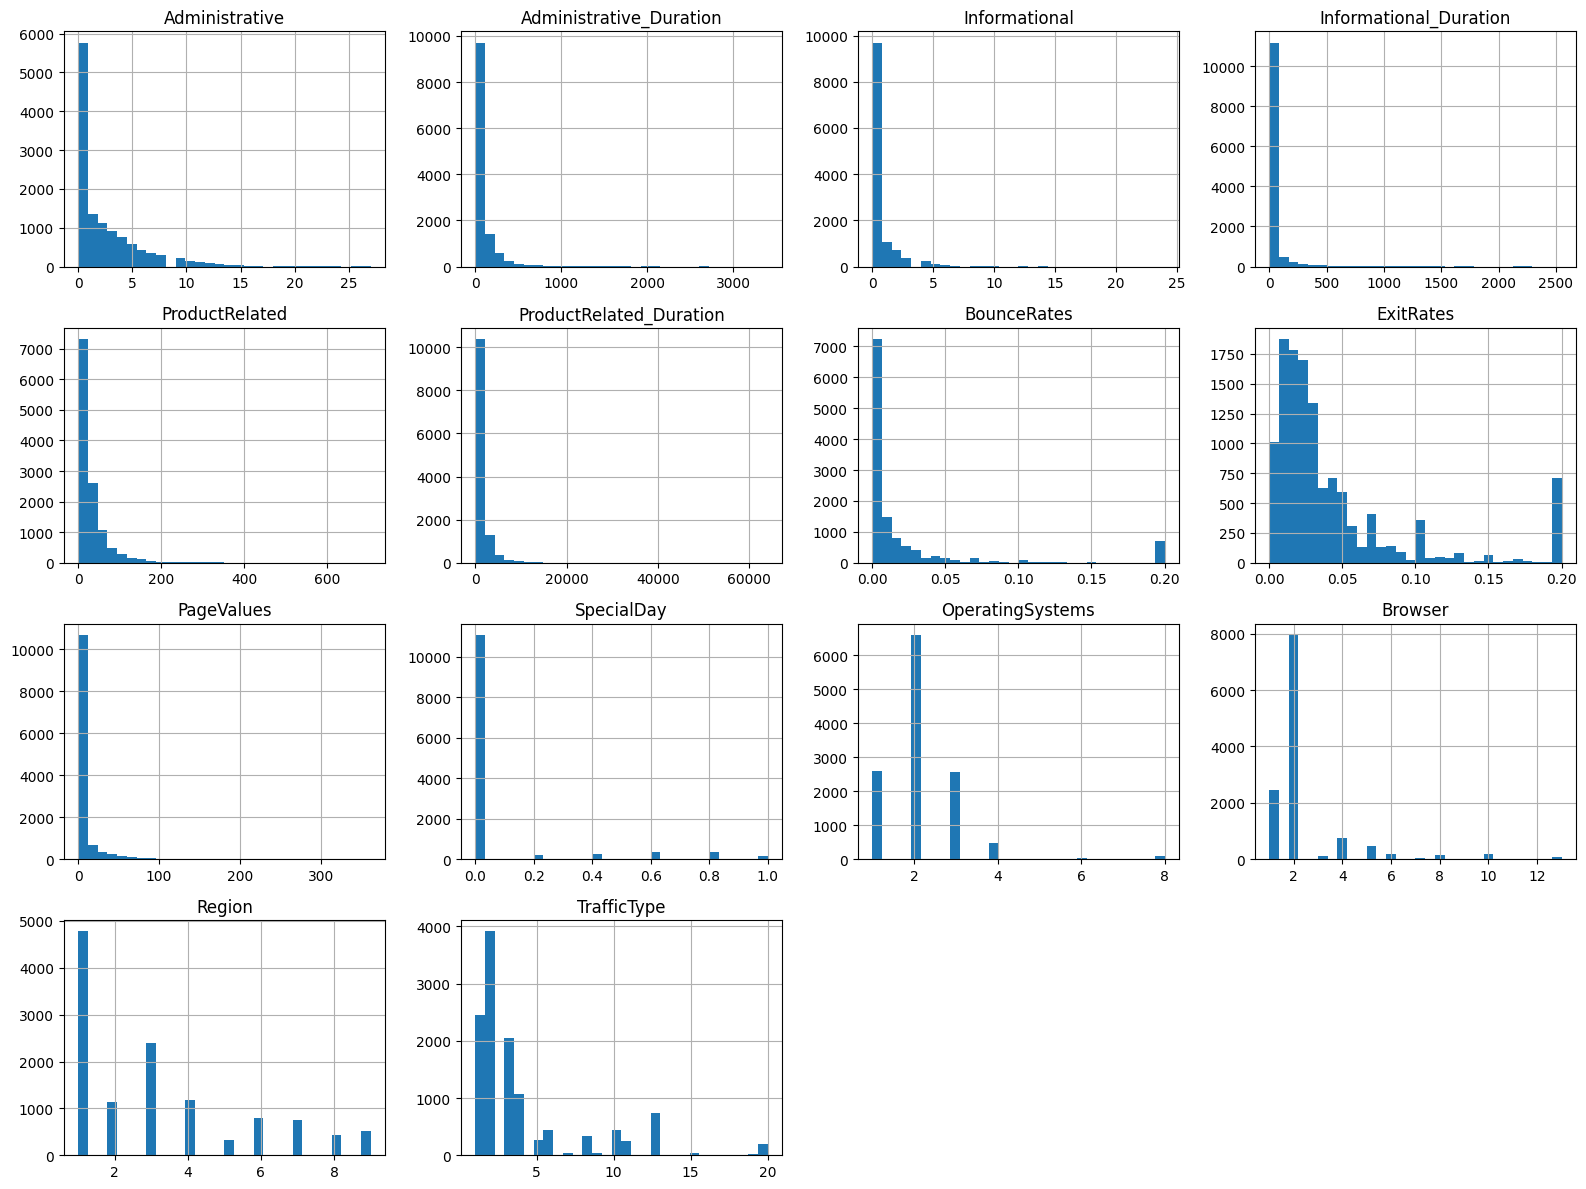

In [4]:
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

Большинство числовых признаков (Administrative_Duration, ProductRelated, BounceRates, ExitRates, PageValues) сильно скошены вправо — много сессий с нулевой или низкой активностью, и длинный хвост активных пользователей.

### 2.4 Корреляции между числовыми признаками

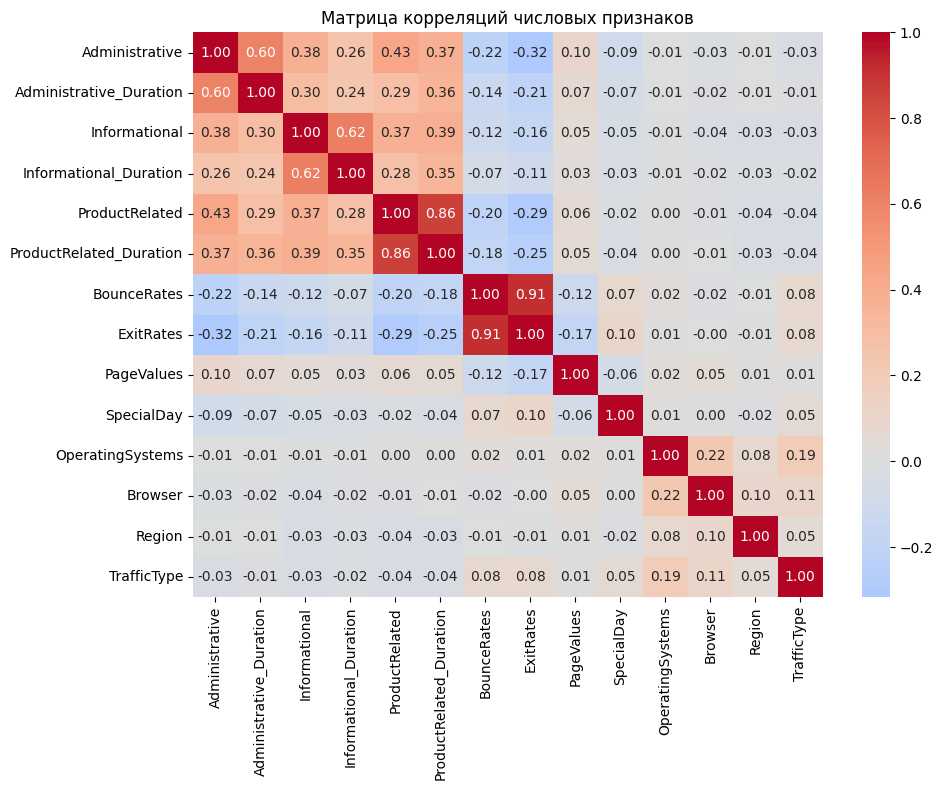

In [5]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()

`BounceRates` и `ExitRates` коррелируют с коэфициентом **0.91**, что косвенно может говорить в пользу гипотез №4 и №5.

### 2.5 Категориальные признаки

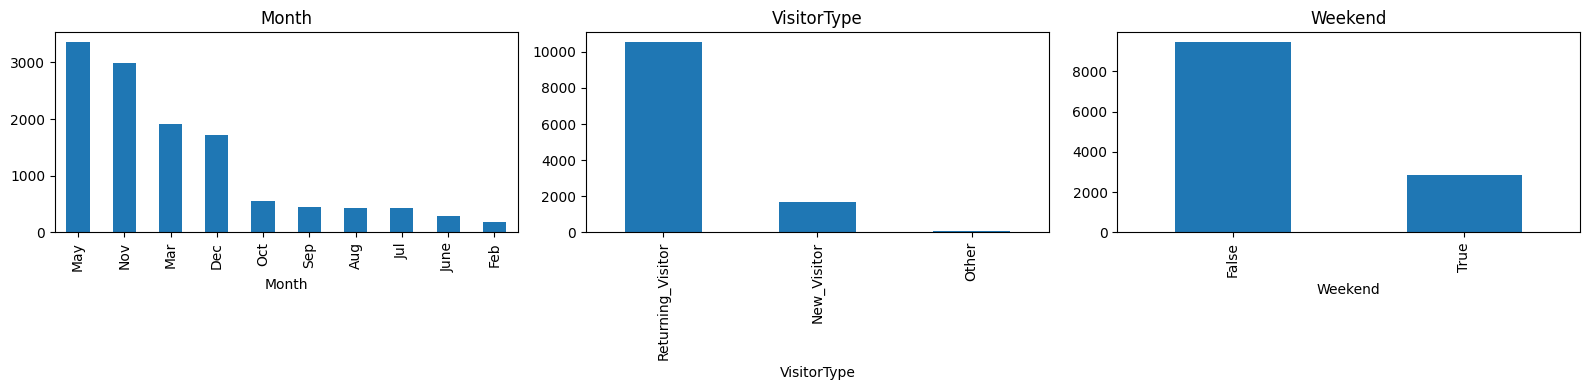

In [8]:
cat_cols = ['Month', 'VisitorType', 'Weekend']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Month` — большинство сессии приходятся на май, ноябрь, март и декабрь. Возможно, это как-то связано с праздниками. Данных за январь и апрель нет, стоит уточнить, возможно сбой в выгрузке из БД. `VisitorType` сильно перекошен в сторону Returning_Visitor. Это стоит учитывать при интерпретации важности этих признаков.

### 2.6 Поиск нелинейности

Обычная корреляция (раздел 2.4) показывает только линейную связь. Чтобы увидеть, насколько связь признака с покупкой нелинейна, разобьём каждый числовой признак на 10 бинов (по квантилям) и посчитаем долю покупок (Revenue=True) в каждом бине. Если бы связь была линейной, точки легли бы примерно на прямую.

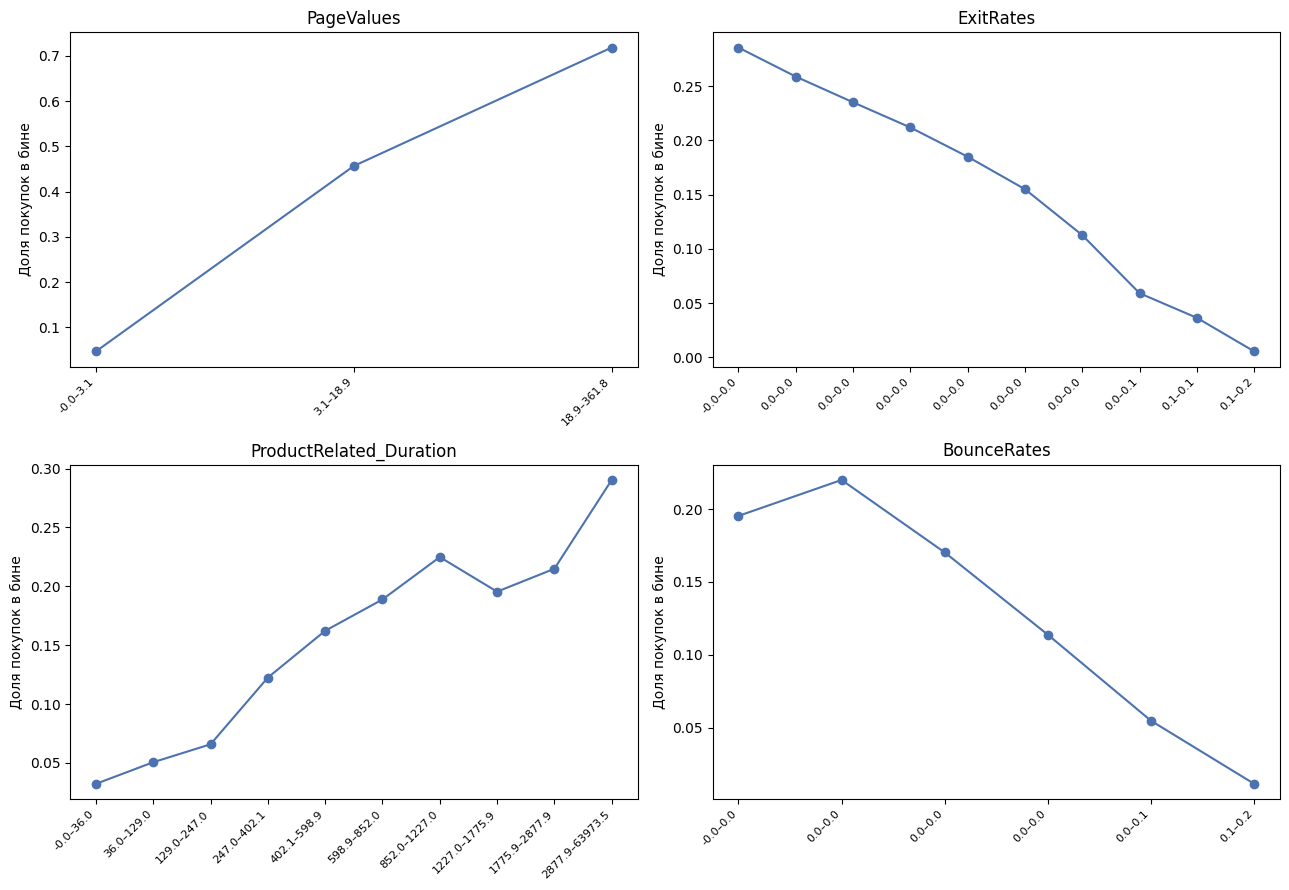

In [9]:
features_to_check = ['PageValues', 'ExitRates', 'ProductRelated_Duration', 'BounceRates']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, col in zip(axes, features_to_check):
    bins = pd.qcut(df[col], q=10, duplicates='drop')
    conv_rate = df['Revenue'].astype(int).groupby(bins, observed=True).mean()
    # середины интервалов для оси X
    x_labels = [f'{b.left:.1f}–{b.right:.1f}' for b in conv_rate.index]

    ax.plot(range(len(conv_rate)), conv_rate.values, marker='o', color='#4C72B0')
    ax.set_xticks(range(len(conv_rate)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Доля покупок в бине')
    ax.set_title(col)

plt.tight_layout()
plt.show()

Хорошо видна нелинейность:

- **`PageValues`** — резкий скачок доли покупок: с ~5% в нижних бинах до ~72% в верхнем. Это далеко не прямая линия — линейная модель такой "скачок" аппроксимирует плохо, а дерево решений может просто поставить порог-разбиение в нужном месте.
- **`ExitRates`** и **`BounceRates`** — доля покупок убывает, но не линейно, а по затухающей кривой (быстрое падение в начале, почти плоский хвост в конце) — больше похоже на экспоненциальное затухание, чем на прямую.
- **`ProductRelated_Duration`** — связь вообще не монотонная: доля покупок растёт, но с провалом в середине диапазона (~1200–1800 секунд) перед новым ростом. Линейная модель принципиально не может отразить немонотонную зависимость — а дерево/лес могут.

Это — эмпирическое обоснование гипотезы 1 (Random Forest превзойдёт LogReg по AUC): сами данные показывают нелинейные и немонотонные зависимости целевой переменной от признаков ещё до того, как мы обучили хоть одну модель.

## 3. Подготовка данных

- Пропусков нет — импутация не требуется.
- Числовые признаки → `StandardScaler` (важно для логистической регрессии и её регуляризации).
- Категориальные (`Month`, `VisitorType`, `Weekend`) → `OneHotEncoder`.
- Разбиение train/test — 80/20, стратифицированное по `Revenue` (из-за дисбаланса классов).

In [6]:
X = df.drop(columns='Revenue')
y = df['Revenue']

cat_cols = ['Month', 'VisitorType', 'Weekend']
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Доля покупок в train:', y_train.mean().round(4), ' в test:', y_test.mean().round(4))

Train: (9864, 17)  Test: (2466, 17)
Доля покупок в train: 0.1547  в test: 0.1549


## 4. Модели: LogReg, Decision Tree, Random Forest

Обучаем три модели через единый `Pipeline` (препроцессинг + классификатор), сравниваем по Accuracy, и особенно по F1 macro и ROC-AUC, т.к. у нас дисбаланс классов. Пока без поиска гиперпараметров по GridSearch.

In [8]:
models = {
    'LogReg (без сильной регуляризации, C=1e6)': LogisticRegression(C=1e6, max_iter=2000),
    'LogReg L2 (Ridge-подобная, C=1.0)': LogisticRegression(C=1.0, max_iter=2000),
    'LogReg L1 (Lasso-подобная, C=1.0)': LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000),
    'Decision Tree (без ограничений)': DecisionTreeClassifier(random_state=42),
    'Random Forest (200 деревьев)': RandomForestClassifier(random_state=42, n_estimators=200),
}

rows = []
fitted_pipes = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('clf', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'f1_macro': f1_score(y_test, pred, average='macro'),
        'roc_auc': roc_auc_score(y_test, proba)
    })
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(rows).set_index('model').round(4)
results_df

,accuracy,f1_macro,roc_auc
model,,,
"LogReg (без сильной регуляризации, C=1e6)",0.8812,0.7072,0.8872
"LogReg L2 (Ridge-подобная, C=1.0)",0.8812,0.7072,0.8876
"LogReg L1 (Lasso-подобная, C=1.0)",0.8816,0.7086,0.8877
Decision Tree (без ограничений),0.8564,0.7264,0.7269
Random Forest (200 деревьев),0.9023,0.7895,0.9212


**Гипотеза 1 (RF > LogReg по AUC):** Random Forest действительно даёт более высокий ROC-AUC, чем все варианты логистической регрессии — модель лучше улавливает нелинейные зависимости.

**Гипотеза 6 (F1 macro заметно ниже accuracy):** видно, что для всех моделей F1 macro ощутимо ниже accuracy, что нормально для дисбаланса классов.

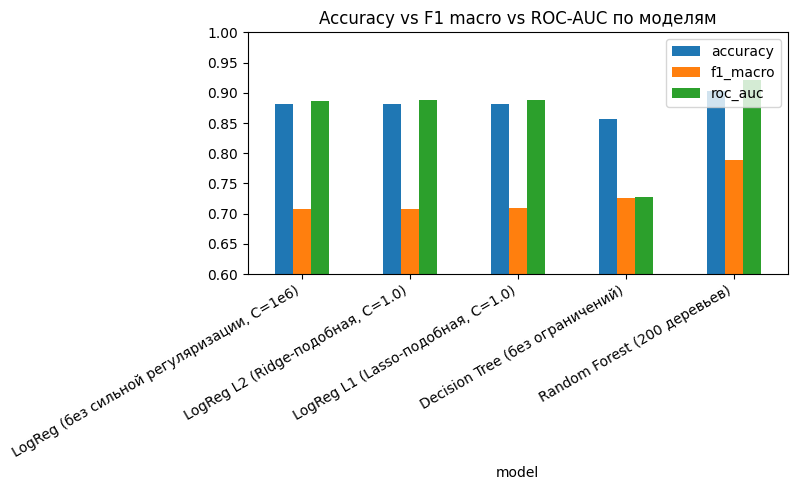

In [10]:
fig, ax = plt.subplots(figsize=(8,5))
results_df[['accuracy', 'f1_macro', 'roc_auc']].plot(kind='bar', ax=ax)
ax.set_title('Accuracy vs F1 macro vs ROC-AUC по моделям')
ax.set_ylim(0.6, 1.0)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Classification report для лучшей модели (Random Forest)

              precision    recall  f1-score   support

 No purchase       0.92      0.97      0.94      2084
    Purchase       0.75      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



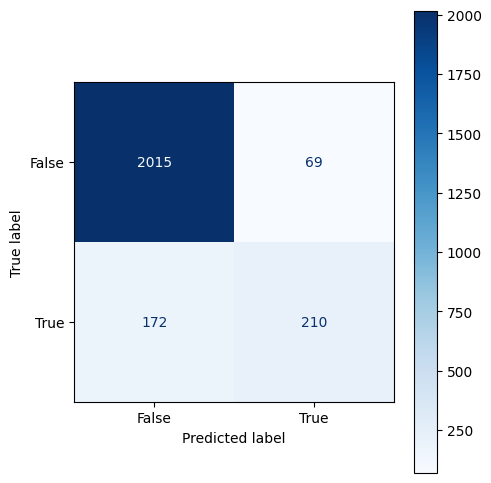

In [11]:
best_pipe = fitted_pipes['Random Forest (200 деревьев)']
pred = best_pipe.predict(X_test)
print(classification_report(y_test, pred, target_names=['No purchase', 'Purchase']))

fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, cmap='Blues')
plt.tight_layout()
plt.show()

## 5. Проверка переобучения дерева решений (гипотеза 2)

Обучаем деревья с разной `max_depth` и сравниваем **F1 macro** на train и test. Accuracy тоже считаем — для сравнения.

In [12]:
depths = [2, 4, 6, 8, 10, 15, 20, None]
depth_rows = []
for depth in depths:
    pipe = Pipeline([('prep', preprocess), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
    pipe.fit(X_train, y_train)
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    depth_rows.append({
        'max_depth': str(depth),
        'train_f1_macro': f1_score(y_train, train_pred, average='macro'),
        'test_f1_macro': f1_score(y_test, test_pred, average='macro'),
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc': accuracy_score(y_test, test_pred),
    })

depth_df = pd.DataFrame(depth_rows)
depth_df

,max_depth,train_f1_macro,test_f1_macro,train_acc,test_acc
0,2,0.757790,0.732246,0.892234,0.886050
1,4,0.785297,0.761220,0.904603,0.896188
2,6,0.829767,0.778185,0.917072,0.893755
3,8,0.858467,0.771412,0.931671,0.890511
4,10,0.897823,0.758017,0.949412,0.882401
5,15,0.978034,0.735248,0.988646,0.863747
6,20,0.998058,0.737323,0.998986,0.864964
7,None,1.000000,0.726443,1.000000,0.856448


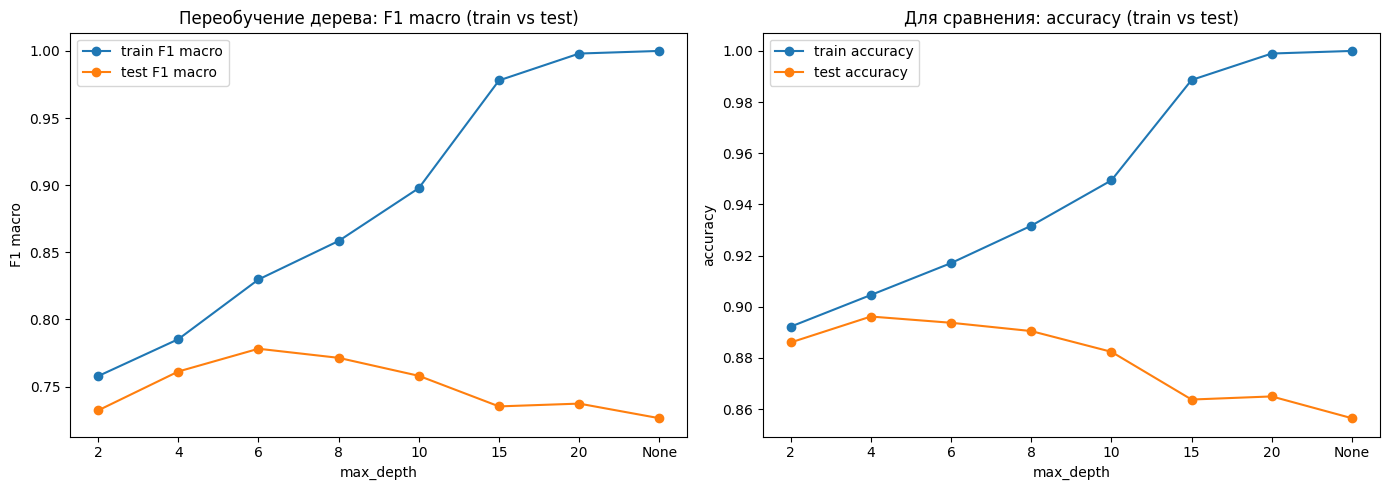

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(depth_df['max_depth'], depth_df['train_f1_macro'], marker='o', label='train F1 macro')
axes[0].plot(depth_df['max_depth'], depth_df['test_f1_macro'], marker='o', label='test F1 macro')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('F1 macro')
axes[0].set_title('Переобучение дерева: F1 macro (train vs test)')
axes[0].legend()

axes[1].plot(depth_df['max_depth'], depth_df['train_acc'], marker='o', label='train accuracy')
axes[1].plot(depth_df['max_depth'], depth_df['test_acc'], marker='o', label='test accuracy')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('accuracy')
axes[1].set_title('Для сравнения: accuracy (train vs test)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Гипотеза 2:** подтверждается на F1 macro. При `max_depth=None` train F1 macro достигает **1.0** (дерево запоминает train целиком), а test F1 macro при этом заметно **ниже**, чем у дерева с оптимальной глубиной (6: test F1 macro ≈ 0.78 против ≈ 0.73 без ограничения глубины).

## 6. Мультиколлинеарность: удаление `BounceRates` (гипотеза 4)

`BounceRates` и `ExitRates` коррелируют на 0.91 (см. EDA). Проверяем, изменится ли AUC логистической регрессии, если убрать `BounceRates`.

In [14]:
num_reduced = [c for c in num_cols if c != 'BounceRates']
preprocess_reduced = ColumnTransformer([
    ('num', StandardScaler(), num_reduced),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipe_full = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
pipe_reduced = Pipeline([('prep', preprocess_reduced), ('clf', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)

auc_full = roc_auc_score(y_test, pipe_full.predict_proba(X_test)[:, 1])
auc_reduced = roc_auc_score(y_test, pipe_reduced.predict_proba(X_test)[:, 1])

print('AUC со всеми признаками:', round(auc_full, 4))
print('AUC без BounceRates:', round(auc_reduced, 4))
print('разница:', round(auc_full - auc_reduced, 4))

AUC со всеми признаками: 0.8876
AUC без BounceRates: 0.8873
разница: 0.0003


**Гипотеза 4:** подтверждается. Разница в AUC при удалении `BounceRates` — тысячные доли, можно сказать, статистически незначима. `ExitRates` действительно несёт почти ту же информацию, и удаление избыточного признака не ухудшает качество модели (а упрощает её интерпретацию и снижает риск нестабильности коэффициентов).

## 7. Ridge (L2) против нерегуляризованной логистической регрессии (гипотеза 5)

In [15]:
auc_no_reg = roc_auc_score(y_test, fitted_pipes['LogReg (без сильной регуляризации, C=1e6)'].predict_proba(X_test)[:, 1])
auc_ridge = roc_auc_score(y_test, fitted_pipes['LogReg L2 (Ridge-подобная, C=1.0)'].predict_proba(X_test)[:, 1])
print('AUC без регуляризации (C=1e6):', round(auc_no_reg, 4))
print('AUC Ridge (C=1.0):', round(auc_ridge, 4))

AUC без регуляризации (C=1e6): 0.8872
AUC Ridge (C=1.0): 0.8876


**Гипотеза 5:** скорее не подтверждается. Ridge действительно немного превосходит нерегуляризованную модель по AUC на тесте, но разница вновь минимальна. Мультиколлинеарность в данных не настолько сильная (после удаления/оставления `BounceRates`/`ExitRates` числа почти не меняются), чтобы регуляризация дала выраженный прирост качества, хотя она может оказаться полезна для стабильности коэффициентов.

## 8. Важность признаков (гипотеза 3)

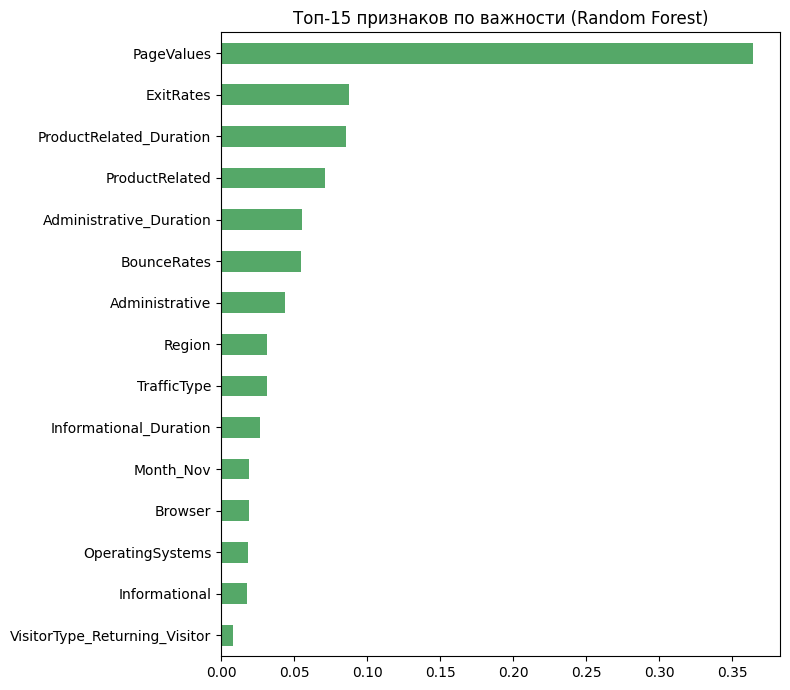

PageValues                 0.364365
ExitRates                  0.087725
ProductRelated_Duration    0.085442
ProductRelated             0.071389
Administrative_Duration    0.055389
BounceRates                0.054962
Administrative             0.043629
Region                     0.031321
TrafficType                0.031282
Informational_Duration     0.026819
dtype: float64

In [16]:
rf_pipe = fitted_pipes['Random Forest (200 деревьев)']
feat_names = num_cols + list(rf_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols))
importances = rf_pipe.named_steps['clf'].feature_importances_
imp_series = pd.Series(importances, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,7))
imp_series.head(15).sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Топ-15 признаков по важности (Random Forest)')
plt.tight_layout()
plt.show()

imp_series.head(10)

**Гипотеза 3:** подтверждается. `PageValues` — безоговорочно самый важный признак (важность ~0.36, в разы выше следующего по значимости `ExitRates`). Это логично: `PageValues` напрямую отражает ценность просмотренных страниц с точки зрения конверсии в покупку.

Признаки `Month` и `VisitorType`, которые визуально выглядели неравномерно распределёнными в EDA, оказались среди наименее важных — поведенческие метрики значат для модели гораздо больше, чем "кто" и "когда" пришёл.

## 9. Отбор признаков: SelectKBest (гипотеза 7)

In [18]:
prep_fitted = preprocess.fit(X_train)
X_train_t = prep_fitted.transform(X_train)
X_test_t = prep_fitted.transform(X_test)

skb = SelectKBest(f_classif, k=10)
X_train_skb = skb.fit_transform(X_train_t, y_train)
X_test_skb = skb.transform(X_test_t)

all_feat_names = num_cols + list(prep_fitted.named_transformers_['cat'].get_feature_names_out(cat_cols))
selected = np.array(all_feat_names)[skb.get_support()]
print('Отобранные топ-10 признаков:', list(selected))

lr_full = LogisticRegression(max_iter=2000).fit(X_train_t, y_train)
lr_skb = LogisticRegression(max_iter=2000).fit(X_train_skb, y_train)

auc_full_feats = roc_auc_score(y_test, lr_full.predict_proba(X_test_t)[:, 1])
auc_skb_feats = roc_auc_score(y_test, lr_skb.predict_proba(X_test_skb)[:, 1])

print('AUC со всеми признаками (~30 после OHE):', round(auc_full_feats, 4))
print('AUC с топ-10 признаками (SelectKBest):', round(auc_skb_feats, 4))

Отобранные топ-10 признаков: [np.str_('Administrative'), np.str_('Administrative_Duration'), np.str_('ProductRelated'), np.str_('ProductRelated_Duration'), np.str_('BounceRates'), np.str_('ExitRates'), np.str_('PageValues'), np.str_('Month_Nov'), np.str_('VisitorType_New_Visitor'), np.str_('VisitorType_Returning_Visitor')]
AUC со всеми признаками (~30 после OHE): 0.8876
AUC с топ-10 признаками (SelectKBest): 0.8853


**Гипотеза 7:** подтверждается. Отбор всего 10 из ~30 признаков (после one-hot кодирования) снижает AUC совсем незначительно (на ~0.002-0.003). Это значит, что основную информацию для предсказания несёт небольшое число признаков, а остальные добавляют мало пользы — можно строить более простую и быструю модель почти без потерь в качестве.

## 10. Подбор гиперпараметров (GridSearchCV) и кросс-валидация

Раздел 4 сравнивал модели с гиперпараметрами, подобранными вручную (нужно было для чистоты сравнения в гипотезах 1, 5, 6). Здесь подбираем гиперпараметры честно, через `GridSearchCV` с 5-фолдовой кросс-валидацией, оптимизируя F1 macro — для всех трёх моделей: Decision Tree, LogReg и Random Forest.

### 10.1 Decision Tree

In [23]:
pipe_gs = Pipeline([('prep', preprocess), ('clf', DecisionTreeClassifier(random_state=42))])
param_grid = {
    'clf__max_depth': [3, 5, 7, 10, 15],
    'clf__min_samples_leaf': [1, 5, 10, 20]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs_tree = GridSearchCV(pipe_gs, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1)
gs_tree.fit(X_train, y_train)

print('Лучшие параметры:', gs_tree.best_params_)
print('Лучший CV f1_macro:', round(gs_tree.best_score_, 4))

tree_pred = gs_tree.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, tree_pred), 4))
print('Test f1_macro:', round(f1_score(y_test, tree_pred, average='macro'), 4))

Лучшие параметры: {'clf__max_depth': 5, 'clf__min_samples_leaf': 20}
Лучший CV f1_macro: 0.7937
Test accuracy: 0.8994
Test f1_macro: 0.7936


Подобранное дерево (`max_depth=5, min_samples_leaf=20`) с существенно ограниченной глубиной обходит по F1 macro дерево без ограничений из раздела 4 — ещё одно подтверждение гипотезы 2 о переобучении неограниченных деревьев.

### 10.2 Логистическая регрессия — подбор силы регуляризации C

In [24]:
pipe_lr = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=2000))])
param_grid_lr = {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring='f1_macro', cv=cv, n_jobs=-1)
gs_lr.fit(X_train, y_train)

print('Лучшие параметры:', gs_lr.best_params_)
print('Лучший CV f1_macro:', round(gs_lr.best_score_, 4))

lr_pred = gs_lr.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, lr_pred), 4))
print('Test f1_macro:', round(f1_score(y_test, lr_pred, average='macro'), 4))

Лучшие параметры: {'clf__C': 100}
Лучший CV f1_macro: 0.7215
Test accuracy: 0.8812
Test f1_macro: 0.7072


Лучшее значение — `C=100`, то есть почти без регуляризации (большой C = слабый штраф). Качество при этом практически не отличается от моделей из раздела 4 (`C=1.0` и `C=1e6`) — логистическая регрессия на этих данных нечувствительна к силе регуляризации, что согласуется с выводом по гипотезе 5: мультиколлинеарность здесь не настолько сильная, чтобы регуляризация давала ощутимый выигрыш.

### 10.3 Random Forest — подбор числа деревьев и глубины

In [25]:
pipe_rf = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(random_state=42))])
param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_leaf': [1, 5]
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring='f1_macro', cv=cv, n_jobs=-1)
gs_rf.fit(X_train, y_train)

print('Лучшие параметры:', gs_rf.best_params_)
print('Лучший CV f1_macro:', round(gs_rf.best_score_, 4))

rf_pred = gs_rf.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, rf_pred), 4))
print('Test f1_macro:', round(f1_score(y_test, rf_pred, average='macro'), 4))

Лучшие параметры: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Лучший CV f1_macro: 0.7992
Test accuracy: 0.9023
Test f1_macro: 0.7895


Лучшая конфигурация (`n_estimators=200, max_depth=None, min_samples_leaf=1`) совпадает с тем, что уже использовалось в разделе 4 «по умолчанию» — grid search подтвердил, что базовый выбор параметров для Random Forest был удачным, дальше улучшать особо некуда без более широкой сетки или других гиперпараметров (`max_features`, `max_samples`).

### 10.4 Итоговое сравнение подобранных моделей через кросс-валидацию

In [26]:
# Кросс-валидация для сравнения стабильности лучших версий каждой модели (не только точечная оценка на одном train/test)
cv_results = {}
for name, model in {
    'LogReg (C=100, лучшее по GridSearch)': LogisticRegression(C=100, max_iter=2000),
    'Decision Tree (max_depth=5, min_samples_leaf=20)': DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42),
    'Random Forest (n_estimators=200)': RandomForestClassifier(random_state=42, n_estimators=200)
}.items():
    pipe = Pipeline([('prep', preprocess), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
    cv_results[name] = scores
    print(f'{name}: f1_macro CV = {scores.mean():.4f} ± {scores.std():.4f}')

LogReg (C=100, лучшее по GridSearch): f1_macro CV = 0.7215 ± 0.0134
Decision Tree (max_depth=5, min_samples_leaf=20): f1_macro CV = 0.7937 ± 0.0191
Random Forest (n_estimators=200): f1_macro CV = 0.7992 ± 0.0106


Decision Tree (max_depth=5, min_samples_leaf=20): f1_macro CV = 0.7937 ± 0.0191


Random Forest (n_estimators=200): f1_macro CV = 0.7992 ± 0.0106


## 11. Подбор порога классификации для бизнес-цели

Если цель — маркетинговая кампания, где важнее **не упустить покупателя** (высокий recall для класса 1), попробуем подобрать порог глядя на то, как precision, recall и F1 меняются вместе с порогом.

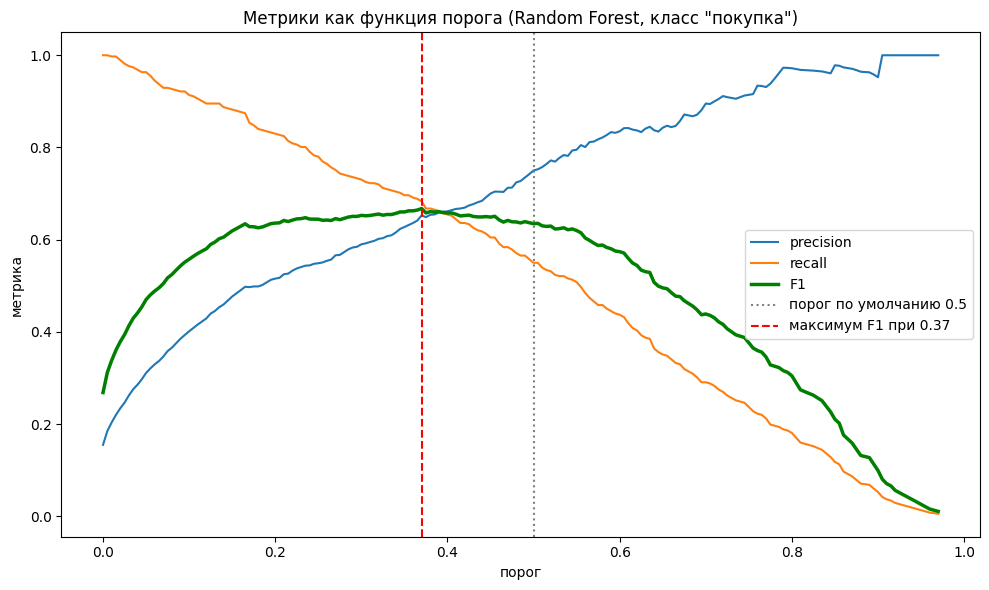

In [28]:
from sklearn.metrics import precision_recall_curve

best_rf = gs_rf.best_estimator_
proba = best_rf.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, proba)
f1_curve = 2 * precision * recall / (precision + recall + 1e-12)

best_idx = f1_curve[:-1].argmax()
best_threshold = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precision[:-1], label='precision')
ax.plot(thresholds, recall[:-1], label='recall')
ax.plot(thresholds, f1_curve[:-1], label='F1', linewidth=2.5, color='green')
ax.axvline(0.5, color='grey', linestyle=':', label='порог по умолчанию 0.5')
ax.axvline(best_threshold, color='red', linestyle='--', label=f'максимум F1 при {best_threshold:.2f}')
ax.set_xlabel('порог')
ax.set_ylabel('метрика')
ax.set_title('Метрики как функция порога (Random Forest, класс "покупка")')
ax.legend()
plt.tight_layout()
plt.show()

Если с точки зрения бизнес-целей мы можем пожертвовать precision и максимизировать recall, то можно выбрать порог порядка 0.1, тогда recall будет около 0.9, т.е. мы найдем в потоке посетителей сайта порядка 90%, кто действительно готов сделать покупку. Но при этом precision будет около 0.4, т.е. в 6 случаев из 10 у нас будет ложное срабатывание. Если такой порог приемлем с точки зрения бизнеса, с точки зрения реакции поседителеей сайта, тогда это отлично порог. 

## 12. Итоги по гипотезам

| № | Гипотеза | Результат | Почему |
|---|----------|-----------|--------|
| 1 | Random Forest превзойдёт LogReg по ROC-AUC | ✅ Подтвердилась | RF даёт заметно более высокий AUC — модель улавливает нелинейные зависимости, недоступные линейной модели |
| 2 | Неограниченное дерево переобучается (train F1 macro↑, test F1 macro↓) | ✅ Подтвердилась | При max_depth=None train F1 macro = 1.0, test F1 macro (≈0.73) ниже, чем у дерева умеренной глубины 6-8 (≈0.78) |
| 3 | PageValues — самый важный признак | ✅ Подтвердилась | Важность PageValues (~0.36) в разы выше любого другого признака |
| 4 | Удаление BounceRates (corr>0.9 с ExitRates) не ухудшит AUC | ✅ Подтвердилась | Разница AUC — тысячные доли, признак избыточен |
| 5 | Ridge обойдёт нерегуляризованную LogReg по AUC | ⚠️ Скорее не подтвердилась | Ridge немного лучше, но разница в пределах шума — мультиколлинеарность в данных не настолько критична |
| 6 | F1 macro заметно ниже accuracy из-за дисбаланса | ✅ Подтвердилась | Разрыв 10-18 п.п. между accuracy и F1 macro у всех моделей |
| 7 | Топ-10 признаков (SelectKBest) не ухудшат качество | ✅ Подтвердилась | AUC падает всего на ~0.002-0.003 при сокращении признаков втрое |

**Общий вывод:** для этой задачи нелинейные модели (Random Forest) работают заметно лучше линейных, ключевой признак — `PageValues`, а точечные усложнения (регуляризация, полный набор признаков) дают минимальный прирост по сравнению с базовым выбором модели и метрики. Из-за дисбаланса классов важно всегда смотреть на F1 macro / ROC-AUC, а не только на accuracy.